Ensemble de ville avec distances

trouver le plus petit chemin qui relie toutes les villes sans passer par une ville plus d'une fois.



3 heuristique 

plus proche voisin

k-opt 

algorithme génétique

1 individu = une solution possible (une parcours de villes) , genere 100 parcours differents , une fonction d'evaluation (le cout du parcours) , selectionne les meilleurs parcours , croisement (melange de 2 parcours pour en faire un nouveau) , mutation (changer l'ordre de 2 villes dans le parcours)

à la fin afficher le parcours le plus court trouvé et sa distance totale.

# TSP (Travelling Salesman Problem)

In [1]:
import pandas as pd
import numpy as np

from pprint import pprint
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'matplotlib'

In [ ]:
class Ville:
    """classe ville"""

    def __init__(self, nom):
        self.nom = nom
        self.__coord_X = None
        self.__coord_Y = None
        self.distance = {}

    def __str__(self):
        return f'{self.nom} coordonées X : {self.__coord_X}, coorodonées Y: {self.__coord_Y}'
    
    def eucledian_distance(self, v2):

        return np.sqrt((v2.coord_X - self.coord_X)**2 + (v2.coord_Y - self.coord_Y)**2)
    

    @property
    def coord_X(self):
        return self.__coord_X
    
    @property
    def coord_Y(self):
        return self.__coord_Y

    @coord_X.setter
    def coord_X(self,x):
        self.__coord_X = x

    @coord_Y.setter
    def coord_Y(self,y):
        self.__coord_Y = y


class France:
    '''liste de ville'''

    def __init__(self):
        self.villes = []
        self.matrix_distance = None
        self.paths = {}
        self.best_path = None


    def __str__(self):
        return f'France: {", ".join([v.nom for v in self.villes])}'
    
    def ajouter_ville(self, ville: Ville):
        self.villes.append(ville)

    def add_ville(self,df):
        for l in df.itertuples():
            ville = Ville(l.Ville)
            ville.coord_X = l.coord_X
            ville.coord_Y = l.coord_Y
            self.ajouter_ville(ville)

    def calculer_distances(self):
        for v in self.villes:
            for ville in self.villes:
                if v.nom != ville.nom:
                    v.distance[f'{ville.nom}'] = v.eucledian_distance(ville)
                else:
                    v.distance[f'{ville.nom}'] = 0

    def build_matrix(self):
        
        n = len(self.villes)
        self.matrix_distance = np.zeros((n,n))

        for i in range(n):
            for j in range(n):
                self.matrix_distance[i][j] = self.villes[i].distance[self.villes[j].nom]
        
        return self.matrix_distance
    

    def get_matrix_with_labels(self):
        noms = [v.nom for v in self.villes]
        return pd.DataFrame(self.matrix_distance, index=noms, columns=noms)
    
    def build_index_ville(self):
        self.index_ville = {v.nom: i for i, v in enumerate(self.villes)}

    def knn_with_matrix(self,start=0):
        """knn"""

        self.build_index_ville()
        
        n = len(self.matrix_distance)

        visited = [False] * n
        path = [self.villes[start].nom]
        visited[self.index_ville[self.villes[start].nom]] = True

        current = start
        for _ in range(n-1):
            nearest = None
            nearest_dist = float('inf')

            for j in range(n):
                if not visited[j] and self.matrix_distance[current][j] < nearest_dist:
                    nearest_dist = self.matrix_distance[current][j]
                    nearest = j
            
            path.append(self.villes[nearest].nom)
            visited[nearest] = True
            current = nearest
        path.append(self.villes[start].nom)  # Retour à la ville de départ

        self.paths[f"{self.villes[start].nom}"] = path
         
    def compute_all_paths(self):
        for i in range(len(self.villes)):
            self.knn_with_matrix(i)
            
    def compute_path_distance(self, path):

        indices = [self.index_ville[nom] for nom in path]
        # créé tous les couples nécessaires pour calculer la distance totale
        rows = indices[:-1]
        print(f"Rows: {rows}")
        cols = indices[1:]
        print(f"Cols: {cols}")

        return np.sum(self.matrix_distance[rows, cols])
    
    def print_distance_from_each_city(self):

        for ville in self.paths.keys():
            print(f"Distance totale partant de {ville} : {self.compute_path_distance(self.paths[ville])}")

    def print_from_a_city(self,nom_ville):

        if nom_ville in self.paths.keys():

            return self.paths[nom_ville]
    
    def get_optimal_path(self):
        
        distances = {}
        for ville in self.paths.keys():
            distances[ville] = self.compute_path_distance(self.paths[ville])
        
        start_point = min(distances, key=distances.get)

        self.best_path = self.paths[start_point]
        
        return start_point, self.paths[start_point], distances[start_point]
    
    def plot_path(self):
        if self.best_path is None:
            return
        
        y = []
        x = []

        for ville_name in self.best_path:
            ville = next(v for v in self.villes if v.nom == ville_name)
            y.append(ville.coord_X)
            x.append(ville.coord_Y)
        
        x = np.array(x)
        y = np.array(y)

        plt.figure(figsize=(10, 6))

        # 1. Tracer les points des villes
        plt.scatter(x, y, color='red', zorder=5)

        u = np.diff(x)
        v = np.diff(y)
        plt.text(x[0]+0.5, y[0]+0.5, 'Point de départ', fontsize=8, c="#000000", ha='center',va='center', backgroundcolor = "#66a0eb",visible=True)
        plt.quiver(x[:-1], y[:-1], u, v, angles='xy', scale_units='xy', scale=1, color="#8C95E4", width=0.005, headwidth=3)
        for i, ville_name in enumerate(self.best_path):
            plt.text(x[i], y[i], ville_name, fontsize=8, c="#000000", ha='right',backgroundcolor = "#66a0eb",visible=True)
        plt.title('Chemin optimal à travers les villes')
        plt.xlabel('Coordonnée X')
        plt.ylabel('Coordonnée Y')
        plt.grid()
        plt.show()
    
    

In [ ]:

def load_data(path:str):
    df = pd.read_csv(path,sep=";",header=None)

    df.columns = ['Ville' , "coord_X", "coord_Y"]

    return df


def process_france_travel(file_path: str, separator: str = ";"):
    try:

        df = pd.read_csv(file_path, sep=separator, header=None)
        df.columns = ['Ville', 'coord_X', 'coord_Y']

        france = France()
        

        for _, row in df.iterrows():
            nouvelle_ville = Ville(row['Ville'])
            nouvelle_ville.coord_X = row['coord_X']
            nouvelle_ville.coord_Y = row['coord_Y']
            france.ajouter_ville(nouvelle_ville)
        

        france.calculer_distances()    
        france.build_matrix()        
        

        france.compute_all_paths()   
        
        print(f"--- Analyse terminée pour : {file_path} ---")
        
        print("\nMatrice de distances :")
        print(france.get_matrix_with_labels())
        
        print("\nChemins trouvés :")
        pprint(france.paths)
        
        print("\nDistance totale par point de départ :")
        print(france.print_distance_from_each_city())
        
        print("\nMeilleur chemin trouvé :")
        start_point, path ,distance = france.get_optimal_path()
        print(f"Point de départ {start_point}")
        print(f"Chemin {path}")
        print(f"Distance : {distance}")
        
        return france

    except FileNotFoundError:
        print(f"Erreur : Le fichier {file_path} est introuvable.")
    except Exception as e:
        print(f"Une erreur est survenue : {e}")



--- Analyse terminée pour : ../data/fr-10.csv ---

Matrice de distances :
                Paris  Bordeaux  Marseille      Lyon  Toulouse      Nice  \
Paris        0.000000  4.973095   6.326457  3.972241  5.330144  7.120736   
Bordeaux     4.973095  0.000000   6.146967  5.497527  2.371294  7.928195   
Marseille    6.326457  6.146967   0.000000  2.519965  3.938071  1.939485   
Lyon         3.972241  5.497527   2.519965  0.000000  4.022312  3.180650   
Toulouse     5.330144  2.371294   3.938071  4.022312  0.000000  5.823140   
Nice         7.120736  7.928195   1.939485  3.180650  5.823140  0.000000   
Nantes       4.234859  2.569377   7.956437  6.556977  4.694562  9.493663   
Montpellier  5.462010  4.623296   1.525776  2.354000  2.433211  3.390335   
Strasbourg   5.400525  9.128595   5.796183  4.051505  8.031260  4.903401   
Lille        1.906665  6.836363   7.687222  5.183621  7.206435  8.102751   

               Nantes  Montpellier  Strasbourg     Lille  
Paris        4.234859     5.46

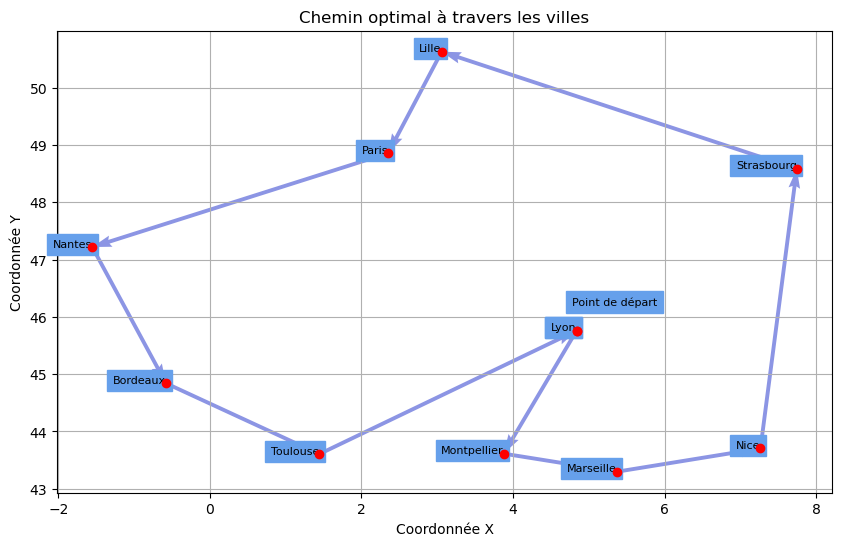

In [ ]:
france10 = process_france_travel("../data/fr-10.csv")

france10.plot_path()



--- Analyse terminée pour : ../data/fr-50.csv ---

Matrice de distances :
                         Paris  Bordeaux  Marseille      Lyon  Toulouse  \
Paris                 0.000000  4.973095   6.326457  3.972241  5.330144   
Bordeaux              4.973095  0.000000   6.146967  5.497527  2.371294   
Marseille             6.326457  6.146967   0.000000  2.519965  3.938071   
Lyon                  3.972241  5.497527   2.519965  0.000000  4.022312   
Toulouse              5.330144  2.371294   3.938071  4.022312  0.000000   
Nice                  7.120736  7.928195   1.939485  3.180650  5.823140   
Nantes                4.234859  2.569377   7.956437  6.556977  4.694562   
Montpellier           5.462010  4.623296   1.525776  2.354000  2.433211   
Strasbourg            5.400525  9.128595   5.796183  4.051505  8.031260   
Lille                 1.906665  6.836363   7.687222  5.183621  7.206435   
Rennes                4.099312  3.454322   8.538739  6.931608  5.486122   
Toulon                6.75

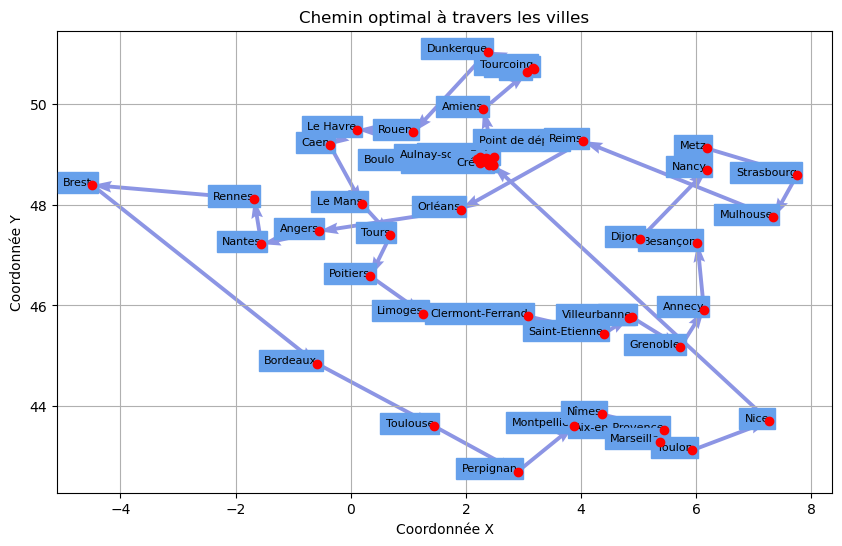

In [ ]:
france50 = process_france_travel("../data/fr-50.csv")
france50.plot_path()

In [ ]:
france50.print_from_a_city("Sevran")

--- Analyse terminée pour : ../data/fr-100.csv ---

Matrice de distances :
                     Paris  Bordeaux  Marseille      Lyon  Toulouse      Nice  \
Paris             0.000000  4.973095   6.326457  3.972241  5.330144  7.120736   
Bordeaux          4.973095  0.000000   6.146967  5.497527  2.371294  7.928195   
Marseille         6.326457  6.146967   0.000000  2.519965  3.938071  1.939485   
Lyon              3.972241  5.497527   2.519965  0.000000  4.022312  3.180650   
Toulouse          5.330144  2.371294   3.938071  4.022312  0.000000  5.823140   
...                    ...       ...        ...       ...       ...       ...   
Bayonne           6.594484  1.622498   6.852735  6.715303  2.926241  8.748903   
Corbeil-Essonnes  0.275318  4.859852   6.051145  3.702014  5.115812  6.855840   
Cagnes-sur-Mer    7.068827  7.817796   1.816565  3.118102  5.705214  0.123708   
Vaulx-en-Velin    4.009014  5.577831   2.521140  0.080375  4.097772  3.132201   
Sevran            0.196634  5.1427

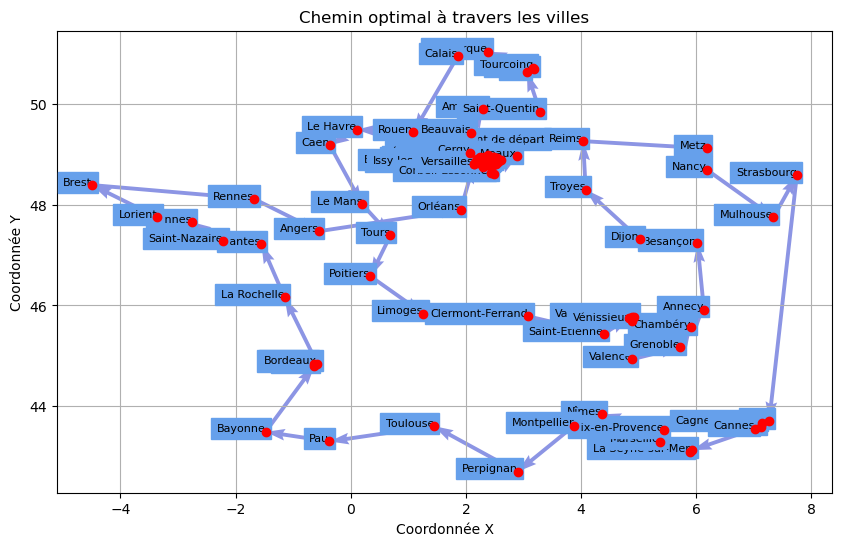

In [ ]:
france100 = process_france_travel("../data/fr-100.csv")
france100.plot_path()

Approche k-opt

In [ ]:
# france = process_france_travel("../data/fr.csv")

